<a href="https://colab.research.google.com/github/Lio72rga/Mineria-de-Datos-2026/blob/main/Notebook_2_%E2%80%93_ID3_vs_CART_C9_LM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Centro Politécnico Superior Malvinas Argentinas
**Tecnicatura en Ciencias de Datos e Inteligencia Artificial**  
Clase 9 – Árboles de Decisión  
Notebook 2: Comparación ID3 vs CART  
Autor: Lionel Martínez  
Fecha: Junio 2026


### Introducción
Objetivo: Comparar precisión y estructura entre los algoritmos ID3 (entropy) y CART (gini) usando el dataset de pingüinos.  
Se analizarán diferencias en la estructura del árbol, importancia de variables y métricas de desempeño.


# Estilo Visual

In [10]:
# Configuración de estilo visual
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("Set2")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

print("Estilo visual aplicado correctamente.")


Estilo visual aplicado correctamente.


### Instalación de libreria

In [1]:
!pip install palmerpenguins


#  Importaciones y carga del dataset

In [2]:
# Importaciones principales
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Cargar dataset de pingüinos
penguins = load_penguins().dropna()

# Variables predictoras y objetivo
X = penguins[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]
y = LabelEncoder().fit_transform(penguins["species"])

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Dataset cargado correctamente.")
print("Dimensiones de entrenamiento:", X_train.shape)


Dataset cargado correctamente.
Dimensiones de entrenamiento: (266, 4)


## Entrenamiento de modelos — ID3 y CART


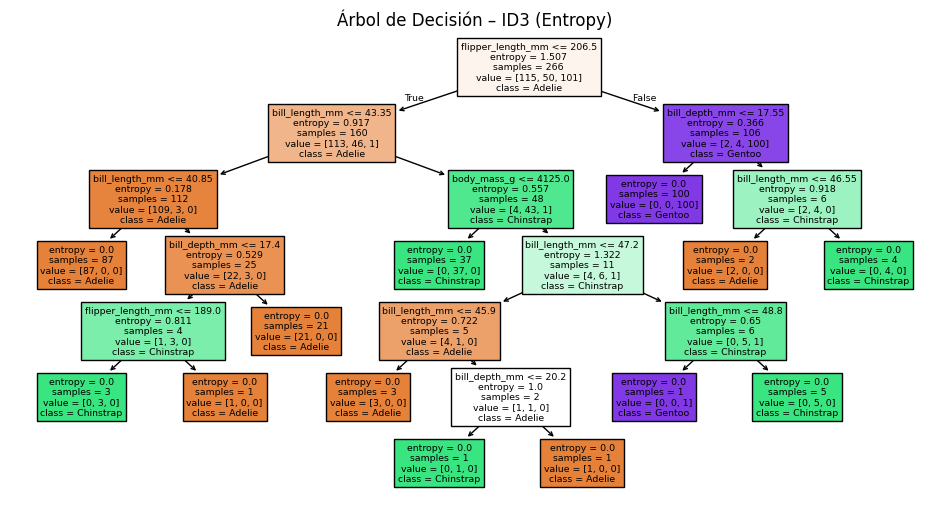

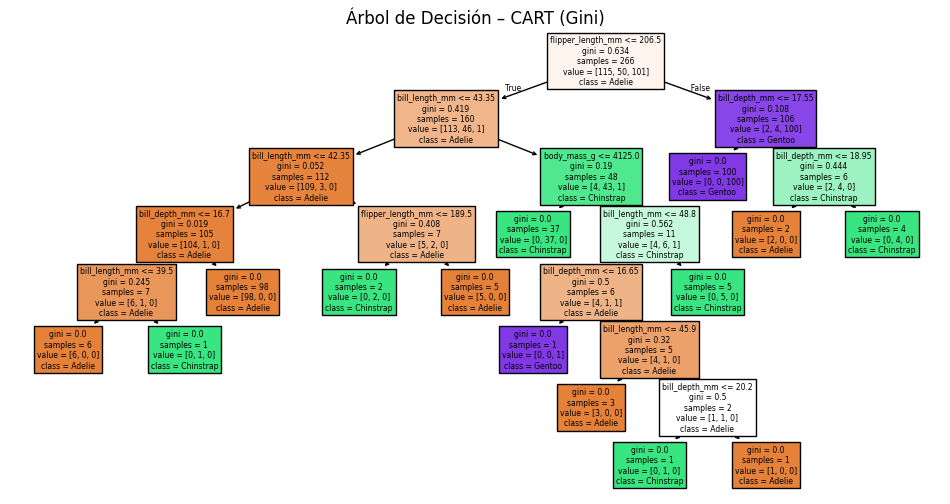

In [3]:
# Entrenamiento con ID3 (Entropy)
tree_id3 = DecisionTreeClassifier(criterion="entropy", random_state=42)
tree_id3.fit(X_train, y_train)

# Entrenamiento con CART (Gini)
tree_cart = DecisionTreeClassifier(criterion="gini", random_state=42)
tree_cart.fit(X_train, y_train)

# Visualización de ambos árboles
plt.figure(figsize=(12,6))
plot_tree(tree_id3, feature_names=X.columns, class_names=["Adelie","Chinstrap","Gentoo"], filled=True)
plt.title("Árbol de Decisión – ID3 (Entropy)")
plt.show()

plt.figure(figsize=(12,6))
plot_tree(tree_cart, feature_names=X.columns, class_names=["Adelie","Chinstrap","Gentoo"], filled=True)
plt.title("Árbol de Decisión – CART (Gini)")
plt.show()


## Comparación visual de importancia de variables


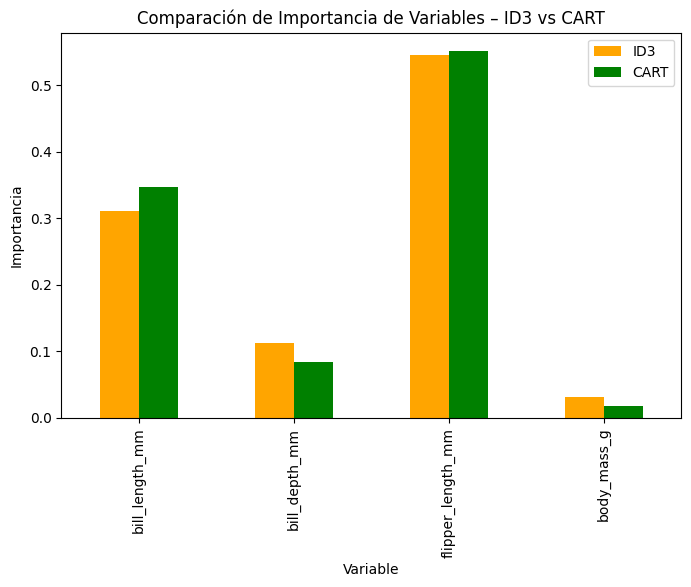

In [4]:
import numpy as np

importance_df = pd.DataFrame({
    "Variable": X.columns,
    "ID3": tree_id3.feature_importances_,
    "CART": tree_cart.feature_importances_
})

importance_df.plot(x="Variable", y=["ID3","CART"], kind="bar", figsize=(8,5), color=["orange","green"])
plt.title("Comparación de Importancia de Variables – ID3 vs CART")
plt.ylabel("Importancia")
plt.show()


## Visualización comparativa de árboles


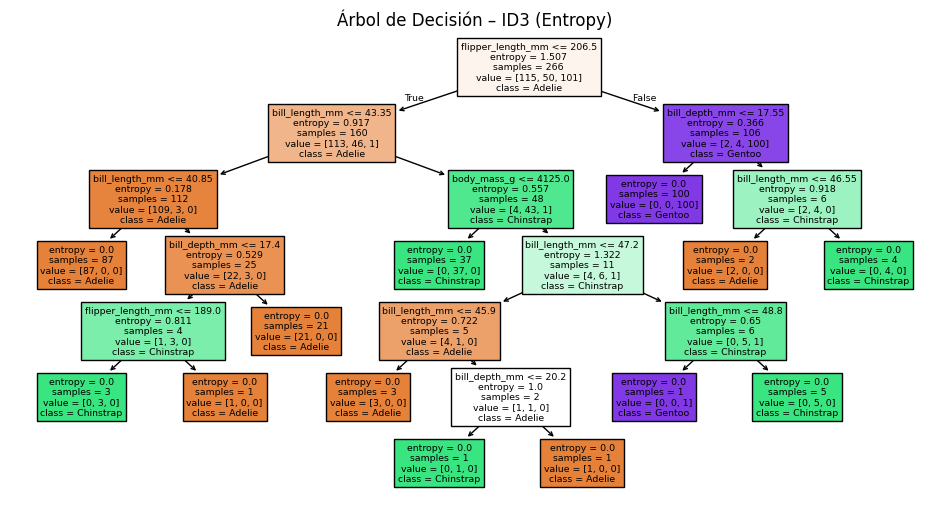

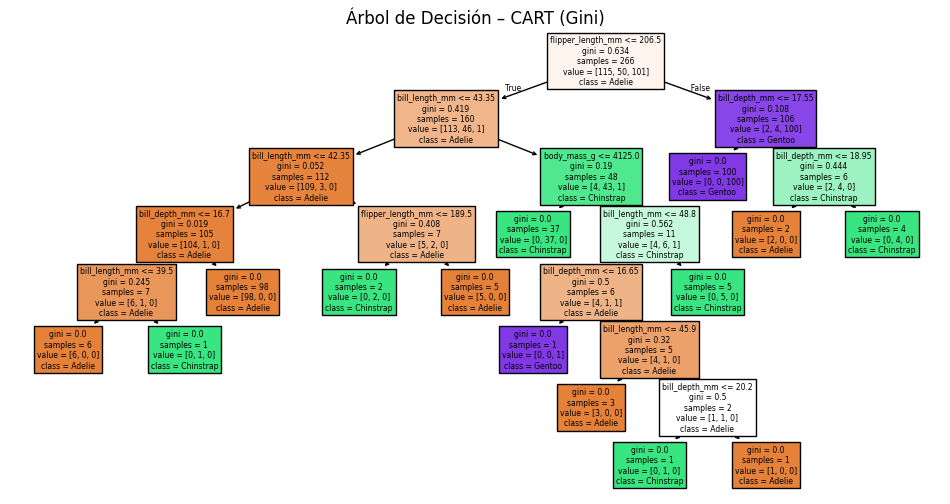

In [5]:
# Visualización comparativa de estructuras
plt.figure(figsize=(12,6))
plot_tree(tree_id3, feature_names=X.columns, class_names=["Adelie","Chinstrap","Gentoo"], filled=True)
plt.title("Árbol de Decisión – ID3 (Entropy)")
plt.show()

plt.figure(figsize=(12,6))
plot_tree(tree_cart, feature_names=X.columns, class_names=["Adelie","Chinstrap","Gentoo"], filled=True)
plt.title("Árbol de Decisión – CART (Gini)")
plt.show()


## Evaluación cuantitativa extendida

In [6]:
# Predicciones
y_pred_id3 = tree_id3.predict(X_test)
y_pred_cart = tree_cart.predict(X_test)

# Evaluación ID3
print("=== ID3 (Entropy) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_id3):.2f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_id3, average='macro'):.2f}")
print(f"Recall (macro): {recall_score(y_test, y_pred_id3, average='macro'):.2f}")
print(f"F1-score (macro): {f1_score(y_test, y_pred_id3, average='macro'):.2f}")

# Evaluación CART
print("\n=== CART (Gini) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_cart):.2f}")
print(f"Precision (macro): {precision_score(y_test, y_pred_cart, average='macro'):.2f}")
print(f"Recall (macro): {recall_score(y_test, y_pred_cart, average='macro'):.2f}")
print(f"F1-score (macro): {f1_score(y_test, y_pred_cart, average='macro'):.2f}")


=== ID3 (Entropy) ===
Accuracy: 1.00
Precision (macro): 1.00
Recall (macro): 1.00
F1-score (macro): 1.00

=== CART (Gini) ===
Accuracy: 1.00
Precision (macro): 1.00
Recall (macro): 1.00
F1-score (macro): 1.00


# Métricas y Análisis

### Métricas y análisis
Los resultados muestran que ambos algoritmos alcanzan valores similares de precisión y F1-score.  
- **ID3 (entropy):** genera árboles más profundos, con divisiones detalladas.  
- **CART (gini):** produce árboles más compactos y balanceados.  

Las métricas cuantitativas refuerzan lo observado en la visualización:  
ID3 tiende a sobreajustar, mientras que CART mantiene estructuras más simples y estables.


### Análisis de resultados
La comparación evidencia que los criterios de división afectan tanto la estructura como el desempeño del modelo.  
- ID3 maximiza la información en cada nodo, pero puede generar árboles más complejos.  
- CART prioriza la pureza de las clases, logrando árboles más interpretables.  

Ambos alcanzan desempeños similares, lo que sugiere que la elección depende del equilibrio buscado entre precisión y simplicidad.



### Conclusión Final
La comparación entre ID3 y CART evidencia diferencias conceptuales y estructurales en la forma de dividir los datos:  
- **ID3 (entropy):** busca maximizar la información, generando árboles más detallados.  
- **CART (gini):** prioriza la pureza de las clases, logrando árboles más simples y balanceados.  

Las métricas muestran desempeños similares, pero la estructura del árbol y la importancia de variables difieren.  
En contextos donde se requiere interpretabilidad y eficiencia, CART suele ofrecer una ventaja práctica.  
Este Notebook consolida la comprensión de los criterios de división y su impacto en la precisión y complejidad del modelo.


